This script takes a pre-optimized ensemble configuration (from a JSON file)
and applies it to a hold-out test set to get final performance metrics.
It is the final step after running the Optuna weight optimization script.

This version has been refactored to include bootstrap resampling to calculate
95% confidence intervals for all relevant performance metrics.

1. Set Up Environment

In [1]:
# --- 1. Imports ---
print("Importing libraries...")
# (Same imports as your original script)
!pip install albumentations torchinfo
!pip install git+https://github.com/qubvel/segmentation_models.pytorch

Importing libraries...
  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-0f1wf7df
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-0f1wf7df
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 4d20629756005085ca0f1f21605c796298ca0c16
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for segmentation_models_pytorch: filename=segmentation_models_pytorch-0.5.1.dev0-py3-none-any.whl size=155806 sha256=cdb203703e13dd7490a60b43054983d47f4f21ca1f89afdeab62e5c2f8076495
  Stored in directory: /tmp/pip-ephem-wheel-cache-vuxj_1ux/wheels/ef/38/4b/267c9bdb27c85ebaa11e9ec77c9059cf2c166ceee760f24429
Successfully built segmentation_models_pytorch


# --- 1. Imports ---

In [2]:
# --- 1. Imports ---
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time
from tqdm import tqdm
import torchvision.models as models
from datetime import datetime
import torch.nn.functional as F
from google.colab import userdata
import random
import seaborn as sns
import shutil
import smtplib
from email.mime.text import MIMEText
from torch.cuda.amp import autocast
import cv2
import segmentation_models_pytorch as smp
import timm
from torchinfo import summary
import pandas as pd
import json
from sklearn.metrics import auc as sklearn_auc
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2
import zipfile

Mounted at /content/drive


In [3]:
# --- 5. Configuration & Setup ---
print("Configuring environment...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ### REFACTORED: Simplified Configuration ###
# This is the only path you need to set. Point it to the output of the Optuna script.
ENSEMBLE_META_PATH = "/content/drive/MyDrive/RESULTS_REPORT_ENSEMBLE/ENSEMBLE_OPTIMIZATION_14_10_2025_05_22_06.json" # <--- UPDATE THIS PATH

BATCH_SIZE = 32
WORKERS = 2
SEED = 42

# --- Dataset Source Path (for the TEST set) ---
DATASET_ZIP_DIR = '/content/drive/MyDrive/IA_MEDICA_SAMPLES/ENSEMBLE_CLEAN'
base_data_dir = '/content/dataset'

# --- Paths to the HOLD-OUT TEST SET ---
test_cancer_image_dir = os.path.join(base_data_dir, 'TEST/CANCER')
test_cancer_mask_dir = os.path.join(base_data_dir, 'TEST/CANCER_MASK')
test_not_cancer_image_dir = os.path.join(base_data_dir, 'TEST/NOT_CANCER')
test_not_cancer_mask_dir = os.path.join(base_data_dir, 'TEST/NOT_CANCER_MASK')

DECODER_DROPOUT = 0

Configuring environment...
Using device: cuda


In [4]:
# --- Seeding ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Configuration complete.")

Configuration complete.


In [5]:
# --- Helper Functions ---
def get_formatted_datetime_string():
  now = datetime.now()
  return now.strftime("%d_%m_%Y_%H_%M_%S")

In [6]:
def get_model(architecture, encoder,validation=False):

  if validation:
    aux_params=None
  else:
    aux_params=dict(dropout=DECODER_DROPOUT, classes=2)

  encoder_weights = None if validation else "imagenet"

  if architecture=="SWIN":
    model = smp.Unet(
    encoder_name=encoder,
    encoder_weights=encoder_weights,
    in_channels=3,
    classes=2,
    activation=None,
    decoder_attention_type=None,
    aux_params=aux_params)
  elif architecture=="DEEPLABV3PLUS":
    model = smp.DeepLabV3Plus(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="INCEPTIONRESNETV2":
    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="DPT":
    model = smp.DPT(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        decoder_readout='ignore',
        aux_params=aux_params)
  elif architecture=="UNET++":
    model = smp.UnetPlusPlus(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="FPN":
    model = smp.FPN(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="SEGFORMER":
    model = smp.Segformer(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="MANET":
    model = smp.MAnet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="UPERNET": # <-- ADD THIS BLOCK
    model = smp.UPerNet(
        encoder_name=encoder,
        encoder_weights="imagenet",
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  else:
    raise ValueError(f"Unknown architecture: {architecture}")

  return model

4. Create Custom Dataset

In [7]:
# --- 8. Dataset Class (Simplified) ---
print("Defining simplified ProstateCancerDataset...")
# Use albumentations for basic transforms (Resize, Normalize, ToTensor)
class ProstateCancerDataset(Dataset):
    def __init__(self, cancer_image_dir, cancer_mask_dir, not_cancer_image_dir, not_cancer_mask_dir):
        # Removed is_train flag as augmentations are pre-applied
        self.cancer_image_dir = cancer_image_dir
        self.cancer_mask_dir = cancer_mask_dir
        self.not_cancer_image_dir = not_cancer_image_dir
        self.not_cancer_mask_dir = not_cancer_mask_dir

        # --- Base Transformation (Applied to ALL data) ---
        self.base_transform = A.Compose([
            A.Resize(224, 224, interpolation=cv2.INTER_LINEAR), # Specify interpolation
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(), # Handles image normalization (scaling) and channel order (C, H, W)
                          # Converts mask to Tensor (C, H, W)
        ])

        # --- Load File Lists ---
        # Defensive listing: check if dirs exist
        self.cancer_images = []
        if os.path.isdir(self.cancer_image_dir):
             self.cancer_images = [f for f in os.listdir(cancer_image_dir) if f.lower().endswith('.png')]
        else: print(f"Warning: Directory not found: {self.cancer_image_dir}")

        self.not_cancer_images = []
        if os.path.isdir(self.not_cancer_image_dir):
             self.not_cancer_images = [f for f in os.listdir(not_cancer_image_dir) if f.lower().endswith('.png')]
        else: print(f"Warning: Directory not found: {self.not_cancer_image_dir}")


        # Combine and store file paths and labels
        self.image_paths = []
        self.mask_paths = []
        self.labels = [] # Still useful maybe for checks later

        for img_name in self.cancer_images:
             img_path = os.path.join(self.cancer_image_dir, img_name)
             mask_path = os.path.join(self.cancer_mask_dir, img_name)
             if os.path.isfile(mask_path): # Ensure mask exists
                 self.image_paths.append(img_path)
                 self.mask_paths.append(mask_path)
                 self.labels.append(1)
             # else: print(f"Warning: Mask missing for cancer image {img_name}")

        for img_name in self.not_cancer_images:
             img_path = os.path.join(self.not_cancer_image_dir, img_name)
             mask_path = os.path.join(self.not_cancer_mask_dir, img_name)
             if os.path.isfile(mask_path): # Ensure mask exists
                 self.image_paths.append(img_path)
                 self.mask_paths.append(mask_path)
                 self.labels.append(0)
             # else: print(f"Warning: Mask missing for non-cancer image {img_name}")

    def __len__(self):
        # Length is simply the total number of valid image/mask pairs found
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        try:
            # Load image using OpenCV (as Albumentations often uses it) - loads BGR
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None: raise IOError("cv2.imread failed for image")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for consistency if needed downstream

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None: raise IOError("cv2.imread failed for mask")

        except Exception as e:
            print(f"Error loading image/mask: {img_path} / {mask_path} - {e}")
            # Return None tuple, handled by collate_fn
            return None, None

        # Create Two-Channel Mask (One-Hot Encode) before transform
        mask = mask.astype(np.uint8)
        two_channel_mask = np.zeros((mask.shape[0], mask.shape[1], 2), dtype=np.float32)
        two_channel_mask[mask == 0, 0] = 1.0  # Background channel
        two_channel_mask[mask != 0, 1] = 1.0  # Cancer channel

        # Apply the base transformations
        try:
            # Pass mask correctly (shape H, W, C)
            augmented = self.base_transform(image=image, mask=two_channel_mask)
            final_image = augmented['image'] # Shape (C, H, W), FloatTensor, Normalized
            final_mask = augmented['mask']   # Shape (C, H, W), FloatTensor, Values 0.0 or 1.0

            # Ensure mask shape is (2, 224, 224)
            if final_mask.shape[0] != 2:
                 resized_mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
                 two_channel_mask_resized = np.zeros((224, 224, 2), dtype=np.float32)
                 two_channel_mask_resized[resized_mask == 0, 0] = 1.0
                 two_channel_mask_resized[resized_mask != 0, 1] = 1.0
                 final_mask = torch.from_numpy(two_channel_mask_resized).permute(2, 0, 1) # HWC -> CHW

            # Final check on mask shape
            if final_mask.shape != (2, 224, 224):
                 raise ValueError(f"Final mask shape is incorrect: {final_mask.shape}")


        except Exception as e:
             print(f"Error applying transform to {os.path.basename(img_path)}: {e}")
             return None, None # Return None tuple on transform error


        return final_image, final_mask

print("Dataset definition complete.")

Defining simplified ProstateCancerDataset...
Dataset definition complete.


In [8]:
# --- 11. Utility Functions (Keep GPU Clear, Error Analysis, Email, Visualize) ---
print("Defining utility functions...")
def clear_gpu():
    # ... (clear_gpu remains the same) ...
    if torch.cuda.is_available():
      print("Clearing GPU cache...");
      torch.cuda.empty_cache();
      gc.collect();
      print("GPU cache cleared.");
      time.sleep(2)

Defining utility functions...


In [9]:
def analyze_ensemble_metrics(models_list, model_weights, test_loader, device, optimal_threshold, num_auc_steps=101):
    """
    Calculates performance metrics for the ensemble.

    ### FINAL & COMPLETE VERSION ###
    This function calculates and reports 95% Confidence Intervals for BOTH:
    1.  MICRO-AVERAGES (Overall pixel-level metrics) using a patient-level bootstrap.
    2.  MACRO-AVERAGES (Mean of per-image scores) using a score-level bootstrap.
    The AUC calculation is fully integrated.
    """
    num_models = len(models_list)
    if not models_list:
      return None
    if model_weights is not None and len(model_weights) != num_models:
        raise ValueError("Length of model_weights must match the number of models.")
    if model_weights is None: # Use equal weights
        model_weights = [1.0 / num_models] * num_models
        print(f"Using equal weights for {num_models} models.")
    else: # Normalize provided weights
        sum_weights = sum(model_weights)
        if not np.isclose(sum_weights, 1.0):
          model_weights = [w/sum_weights for w in model_weights]; print(f"Normalized weights: {model_weights}")
        else:
          print(f"Using provided weights: {model_weights}")

    for model in models_list:
      model.eval()

    # --- Accumulators for AUC ---
    auc_thresholds = np.linspace(0.0, 1.0, num_auc_steps)
    tp_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    fp_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    fn_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    tn_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)

    # --- List to store per-image stats for BOTH bootstrapping methods ---
    per_image_stats = []
    batches_skipped = 0

    print(f"Running Ensemble test evaluation with optimal threshold: {optimal_threshold:.4f}")
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Ensemble Test", leave=False)
        for batch_data in pbar:
            if batch_data is None or batch_data[0] is None:
              batches_skipped+=1
              continue
            images, masks = batch_data
            images=images.to(device, non_blocking=True)
            true_indices = torch.argmax(masks, dim=1).int()
            current_batch_size = images.size(0)
            if current_batch_size == 0: continue

            # --- Ensemble Prediction ---
            sum_weighted_probs_cancer = torch.zeros_like(images[:, 0, :, :], device=device, dtype=torch.float32)
            valid_model_outputs = 0
            for i, model in enumerate(models_list):
                try:
                    with torch.amp.autocast('cuda'):
                        outputs_raw = model(images)
                        outputs = outputs_raw[0] if isinstance(outputs_raw, tuple) else outputs_raw
                        if outputs.shape[1] == 2:
                            probs_cancer = torch.softmax(outputs, dim=1)[:, 1, :, :]
                        else:
                            probs_cancer = torch.sigmoid(outputs).squeeze(1)
                        sum_weighted_probs_cancer += model_weights[i] * probs_cancer
                        valid_model_outputs += 1
                except Exception as model_err:
                    print(f"Warning: Model {i} failed on a batch: {model_err}. Skipping.")
                    continue
            if valid_model_outputs == 0:
                batches_skipped += 1
                continue
            ensemble_probs_cancer = sum_weighted_probs_cancer
            ensemble_preds_opt = (ensemble_probs_cancer > optimal_threshold).int()
            true_indices_dev = true_indices.to(device)

            # --- Store per-image confusion matrix stats ---
            for j in range(current_batch_size):
                pred_single, true_single = ensemble_preds_opt[j], true_indices_dev[j]
                tp = ((pred_single == 1) & (true_single == 1)).sum().item()
                fp = ((pred_single == 1) & (true_single == 0)).sum().item()
                fn = ((pred_single == 0) & (true_single == 1)).sum().item()
                tn = ((pred_single == 0) & (true_single == 0)).sum().item()
                per_image_stats.append({'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})

            # --- Accumulate counts for AUC curve points ---
            ensemble_probs_cancer_cpu = ensemble_probs_cancer.cpu()
            true_indices_cpu = true_indices.cpu()
            for i, auc_thresh in enumerate(auc_thresholds):
                preds_binary_auc = (ensemble_probs_cancer_cpu > auc_thresh).int()
                tp_auc_counts[i] += ((preds_binary_auc == 1) & (true_indices_cpu == 1)).sum().item()
                fp_auc_counts[i] += ((preds_binary_auc == 1) & (true_indices_cpu == 0)).sum().item()
                fn_auc_counts[i] += ((preds_binary_auc == 0) & (true_indices_cpu == 1)).sum().item()
                tn_auc_counts[i] += ((preds_binary_auc == 0) & (true_indices_cpu == 0)).sum().item()

            del images, masks, true_indices, sum_weighted_probs_cancer, ensemble_preds_opt, true_indices_dev
            del ensemble_probs_cancer_cpu, true_indices_cpu
            torch.cuda.empty_cache()

    # --- Post-Loop Calculations ---
    if not per_image_stats:
        print("Error: No images were processed successfully.")
        return None

    n_bootstrap_samples = 1000
    n_images = len(per_image_stats)
    stats_array = np.array([[s['tp'], s['fp'], s['fn'], s['tn']] for s in per_image_stats])
    metric_keys = ['dice', 'iou', 'accuracy', 'tpr', 'tnr', 'precision', 'fpr', 'fnr']

    # --- 1. MICRO-AVERAGE Calculation with Patient-Level Bootstrap CI ---
    print("\nCalculating Micro-Averaged Metrics and 95% CIs (Patient-Level Bootstrap)...")
    bootstrap_micro_metrics = {key: np.zeros(n_bootstrap_samples) for key in metric_keys}
    for i in range(n_bootstrap_samples):
        indices = np.random.choice(range(n_images), size=n_images, replace=True)
        bootstrap_stats_sample = stats_array[indices]
        tp, fp, fn, tn = bootstrap_stats_sample.sum(axis=0)
        bootstrap_micro_metrics['dice'][i] = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        bootstrap_micro_metrics['iou'][i] = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        bootstrap_micro_metrics['accuracy'][i] = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        bootstrap_micro_metrics['tpr'][i] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        bootstrap_micro_metrics['tnr'][i] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        bootstrap_micro_metrics['precision'][i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        bootstrap_micro_metrics['fpr'][i] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        bootstrap_micro_metrics['fnr'][i] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # Calculate the "true" point estimates for micro-metrics from the full dataset
    tp, fp, fn, tn = stats_array.sum(axis=0)
    final_micro_metrics = {
        'point_estimate': {
            'dice': (2*tp)/(2*tp+fp+fn), 'iou': tp/(tp+fp+fn), 'accuracy':(tp+tn)/(tp+tn+fp+fn),
            'tpr': tp/(tp+fn), 'tnr': tn/(tn+fp), 'precision':tp/(tp+fp), 'fpr':fp/(fp+tn), 'fnr': fn/(fn+tp)
        },
        'ci': {metric: np.percentile(bootstrap_micro_metrics[metric], [2.5, 97.5]) for metric in metric_keys}
    }

    # --- 2. MACRO-AVERAGE Calculation with Score-Level Bootstrap CI ---
    print("Calculating Macro-Averaged Metrics and 95% CIs (Score-Level Bootstrap)...")
    per_image_scores = {key: np.zeros(n_images) for key in metric_keys}
    for i, s in enumerate(stats_array):
        tp, fp, fn, tn = s[0], s[1], s[2], s[3]
        per_image_scores['dice'][i] = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        per_image_scores['iou'][i] = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        per_image_scores['accuracy'][i] = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        per_image_scores['tpr'][i] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        per_image_scores['tnr'][i] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_image_scores['precision'][i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        per_image_scores['fpr'][i] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        per_image_scores['fnr'][i] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    bootstrap_macro_means = {key: np.zeros(n_bootstrap_samples) for key in metric_keys}
    for i in range(n_bootstrap_samples):
        indices = np.random.choice(range(n_images), size=n_images, replace=True)
        for metric in metric_keys:
            bootstrap_macro_means[metric][i] = np.mean(per_image_scores[metric][indices])

    final_macro_metrics = {
        'point_estimate': {metric: np.mean(per_image_scores[metric]) for metric in metric_keys},
        'ci': {metric: np.percentile(bootstrap_macro_means[metric], [2.5, 97.5]) for metric in metric_keys}
    }

    # --- 3. AUC Calculation (restored) ---
    auc_score = 0.0
    print("Calculating Ensemble AUC from accumulated counts...")
    try:
        total_pos = tp_auc_counts[0] + fn_auc_counts[0]
        total_neg = fp_auc_counts[0] + tn_auc_counts[0]
        if total_pos > 0 and total_neg > 0:
            tpr_values = tp_auc_counts / total_pos
            fpr_values = fp_auc_counts / total_neg
            sort_indices = np.argsort(fpr_values)
            fpr_final = np.concatenate(([0.], fpr_values[sort_indices], [1.]))
            tpr_final = np.concatenate(([0.], tpr_values[sort_indices], [1.]))
            fpr_final_unique, unique_indices = np.unique(fpr_final, return_index=True)
            tpr_final_unique = tpr_final[unique_indices]
            if len(fpr_final_unique) > 1:
                auc_score = sklearn_auc(fpr_final_unique, tpr_final_unique)
    except Exception as e: print(f"AUC Calculation Error: {e}")
    finally: del tp_auc_counts, fp_auc_counts, fn_auc_counts, tn_auc_counts; gc.collect()

    # --- 4. Final Reporting ---
    print("\n" + "="*25 + " Final Performance Summary " + "="*25)
    print("\n--- Overall Pixel-Level Metrics (Micro-Averages) ---")
    for metric in sorted(metric_keys):
        pe = final_micro_metrics['point_estimate'][metric]
        ci = final_micro_metrics['ci'][metric]
        print(f"  {metric.replace('_',' ').title():<12}: {pe:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")
    print(f"  {'AUC':<12}: {auc_score:.4f}  (CI not calculated via bootstrap)")

    print("\n--- Mean Per-Image Metrics (Macro-Averages) ---")
    for metric in sorted(metric_keys):
        pe = final_macro_metrics['point_estimate'][metric]
        ci = final_macro_metrics['ci'][metric]
        print(f"  {metric.replace('_',' ').title():<12}: {pe:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")

    # --- 5. Plotting ---
    tp, fp, fn, tn = stats_array.sum(axis=0)
    cm = np.array([[tn, fp], [fn, tp]])
    plt.figure(figsize=(8, 6));
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Pred NoCancer','Pred Cancer'], yticklabels=['True NoCancer','True Cancer']);
    plt.xlabel('Predicted');
    plt.ylabel('True');
    plt.title('Ensemble Confusion Matrix (%)');
    plt.show()

    return {
        'micro_averaged_metrics': final_micro_metrics,
        'macro_averaged_metrics': final_macro_metrics,
        'auc': auc_score
    }

In [10]:
def visualize_ensemble_predictions(models_list, model_weights, dataloader, device, threshold, num_samples=5):
    # ... (Similar structure to evaluate_ensemble, but plots images) ...
    num_models=len(models_list)
    if model_weights is None:
      model_weights = [1.0/num_models]*num_models
    for model in models_list:
      model.eval()
    print(f"Visualizing {num_samples} ENSEMBLE samples (Threshold={threshold:.4f})...")
    with torch.no_grad():
        try:
          batch_data = next(iter(dataloader))
        except StopIteration:
          print("DataLoader empty.");
          return
        if batch_data is None:
          print("Cannot load batch.");
          return
        images, masks = batch_data;
        actual_batch_size = images.shape[0];
        num_samples = min(num_samples, actual_batch_size)
        if num_samples == 0:
          print("No samples.");
          return
        sample_indices = random.sample(range(actual_batch_size), num_samples)
        images_vis = images[sample_indices].to(device);
        masks_vis = masks[sample_indices] # Keep mask on CPU
        true_classes = torch.argmax(masks_vis, dim=1).numpy() # N, H, W

        # Get ensemble predictions
        sum_weighted_probs_cancer = torch.zeros_like(images_vis[:,0,:,:], device=device, dtype=torch.float32)
        for i, model in enumerate(models_list):
             with torch.amp.autocast('cuda'):
                  outputs_raw=model(images_vis);
                  if isinstance(outputs_raw, tuple):
                    outputs = outputs_raw[0]
                  else:
                    outputs = outputs_raw
                  if not isinstance(outputs, torch.Tensor):
                    continue
                  probs_cancer=torch.softmax(outputs,dim=1)[:,1,:,:]; sum_weighted_probs_cancer+=model_weights[i]*probs_cancer
        ensemble_probs_cancer = sum_weighted_probs_cancer # Already averaged if weights sum to 1
        ensemble_preds = (ensemble_probs_cancer > threshold).cpu().numpy().astype(np.uint8) # N, H, W

        images_np = images_vis.cpu().numpy() # N, C, H, W
        for j in range(num_samples):
            image = images_np[j].transpose((1,2,0));
            mean=np.array([0.485,0.456,0.406]);
            std=np.array([0.229,0.224,0.225]);
            image=std*image+mean;
            image=np.clip(image,0,1);
            pred_mask=ensemble_preds[j];
            true_mask=true_classes[j]
            fig,axes=plt.subplots(1,3,figsize=(15,5));
            axes[0].imshow(image);
            axes[0].set_title(f"Image {j+1}");
            axes[0].axis('off');
            axes[1].imshow(image);
            axes[1].imshow(np.ma.masked_where(pred_mask==0,pred_mask),cmap='jet',alpha=0.5);
            axes[1].set_title("Ensemble Pred Mask");
            axes[1].axis('off');
            axes[2].imshow(image);
            axes[2].imshow(np.ma.masked_where(true_mask==0,true_mask),cmap='jet',alpha=0.5);
            axes[2].set_title("True Mask");
            axes[2].axis('off');
            plt.tight_layout();
            plt.show()

print("Utility functions defined.")

Utility functions defined.


In [23]:
def print_scientific_analysis_report(metrics_results):
    """
    Prints a detailed, objective, and scientific guide for interpreting the model's
    performance by providing context, benchmarks, and explanations for the results.
    """
    if not metrics_results:
        print("\nMetrics object is empty. Cannot generate report.")
        return

    micro = metrics_results.get('micro_averaged_metrics', {}).get('point_estimate', {})
    macro = metrics_results.get('macro_averaged_metrics', {}).get('point_estimate', {})
    auc = metrics_results.get('auc')

    if not micro or not macro or auc is None:
        print("\nMetrics object is missing required data. Cannot generate full report.")
        return

    print("\n" + "="*30 + " Scientific Performance Analysis " + "="*30)
    print("\nThis report provides a scientific context for your model's results. It is crucial to")
    print("evaluate these numbers against the specific requirements of your research or clinical goal.")

    print("\n\n" + "-"*25 + " Analysis of Key Metrics " + "-"*25)

    # --- Dice Coefficient ---
    print("\n[--- Segmentation Quality: Dice Coefficient ---]")
    print("  - Definition: Measures the spatial overlap between the predicted and true masks. The ideal value is 1.0.")
    print(f"  - Your Micro-Average Dice is {micro['dice']:.4f}. This metric reflects the model's overall pixel-level")
    print("    accuracy. In medical segmentation, scores > 0.90 are often associated with excellent spatial")
    print("    agreement, while scores of 0.70-0.90 may be clinically useful depending on the application.")
    print(f"  - Your Macro-Average Dice is {macro['dice']:.4f}. This value is the average of individual image scores.")
    print("    A significant difference between the Micro and Macro Dice often indicates a dataset with a")
    print("    large proportion of true-negative images, where the per-image Dice score is correctly 0.")

    # --- FNR & TPR (Sensitivity) ---
    print("\n[--- Clinical Reliability: Sensitivity (1 - FNR) ---]")
    print("  - Definition (FNR): The False Negative Rate, or 'Miss Rate'. It represents the proportion of")
    print("    cancerous cases (or pixels) that the model failed to detect. The ideal value is 0.0.")
    print("  - Interpretation: This metric is often critical for safety. A lower FNR indicates higher sensitivity")
    print("    and a reduced risk of missing a diagnosis.")
    print(f"  - Your model's Macro-Average FNR is {macro['fnr']:.4f}. This suggests that on a per-image basis,")
    print(f"    an estimated {macro['fnr']:.2%} of positive cases were missed by the model.")

    # --- FPR & TNR (Specificity) ---
    print("\n[--- Clinical Reliability: Specificity (1 - FPR) ---]")
    print("  - Definition (FPR): The False Positive Rate, or 'False Alarm Rate'. It represents the proportion")
    print("    of healthy cases (or pixels) that were incorrectly classified as cancerous. The ideal value is 0.0.")
    print("  - Interpretation: This metric is important for clinical efficiency. A lower FPR indicates higher")
    print("    specificity, reducing unnecessary follow-up procedures on healthy cases.")
    print(f"  - Your model's Macro-Average FPR is {macro['fpr']:.4f}. This suggests that on a per-image basis,")
    print(f"    an estimated {macro['fpr']:.2%} of negative cases triggered a false alarm.")

    # --- AUC ---
    print("\n[--- Overall Discriminative Power: AUC ---]")
    print("  - Definition: The Area Under the ROC Curve. It measures the model's ability to distinguish between")
    print("    positive and negative pixels across all possible thresholds. An AUC of 0.5 is random chance.")
    print("  - Ideal Value: 1.0 (perfect separability).")
    print(f"  - Your model's AUC is {auc:.4f}. As a benchmark, values above 0.95 are typically considered to")
    print("    reflect excellent discriminative power between the classes.")

    print("\n\n" + "="*25 + " How to Form a Conclusion " + "="*25)
    print("A robust model typically demonstrates a combination of strengths:")
    print("  1. High Technical Skill: Indicated by a high Micro-Average Dice and a high AUC.")
    print("  2. High Safety & Sensitivity: Indicated by a low Macro-Average FNR.")
    print("  3. High Efficiency & Specificity: Indicated by a low Macro-Average FPR.")
    print("\nEvaluate the trade-offs between these metrics based on the intended clinical application.")
    print("For a screening tool, a very low FNR might be prioritized, while for a confirmatory tool,")
    print("a very low FPR might be more critical.")
    print("="*80)

In [12]:
# ==============================================================================
# --- Main Ensemble Evaluation ---
# ==============================================================================
print(f"\n{'='*25} Starting Final Ensemble Evaluation on Test Set {'='*25}")

# --- Extract Dataset ---
print("Extracting test dataset...")
fold_zip_filename = 'MASTER_SET_1.zip' # Assuming test data is in this zip
fold_zip_path = os.path.join(DATASET_ZIP_DIR, fold_zip_filename)
with zipfile.ZipFile(fold_zip_path, 'r') as z:
    z.extractall(base_data_dir)


========================= Starting Final Ensemble Evaluation on Test Set =========================
Extracting test dataset...


In [13]:
# --- Create Test DataLoader ---
print("\nCreating Test DataLoader...")
def collate_fn(batch):
    batch = list(filter(lambda x: x is not None and x[0] is not None, batch))
    return torch.utils.data.dataloader.default_collate(batch) if batch else (None, None)

test_ds = ProstateCancerDataset(test_cancer_image_dir, test_cancer_mask_dir, test_not_cancer_image_dir, test_not_cancer_mask_dir)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True, collate_fn=collate_fn)
print(f"Test dataset size: {len(test_ds)}")


Creating Test DataLoader...
Test dataset size: 11766


In [14]:
# ### REFACTORED: Step 1 - Load the pre-computed ensemble recipe (NEW, IMPROVED VERSION) ###
print(f"\nLoading ensemble recipe from: {ENSEMBLE_META_PATH}")
if not os.path.exists(ENSEMBLE_META_PATH):
    raise FileNotFoundError(f"Ensemble metadata file not found! Path: {ENSEMBLE_META_PATH}")

with open(ENSEMBLE_META_PATH, 'r') as f:
    ensemble_recipe = json.load(f)


Loading ensemble recipe from: /content/drive/MyDrive/RESULTS_REPORT_ENSEMBLE/ENSEMBLE_OPTIMIZATION_14_10_2025_05_22_06.json


In [15]:
# Extract the necessary information from the new format
optimal_threshold = ensemble_recipe['optimal_ensemble_threshold']
constituent_models_info = ensemble_recipe['constituent_models'] # This list now contains the weights

# Extract weights and model info in a single loop
optimal_weights = [model_info['ensemble_weight'] for model_info in constituent_models_info]

n_models = len(constituent_models_info)

In [16]:
print(ensemble_recipe)

{'best_ensemble_metric': {'dice': 0.9678436517715454}, 'optimal_ensemble_threshold': 0.4059596061706543, 'constituent_models': [{'architecture': 'DPT', 'encoder': 'tu-vit_large_patch16_224.augreg_in21k_ft_in1k', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/DPT_tu-vit_large_patch16_224.augreg_in21k_ft_in1k_13_10_2025_19_47_57_E6_VLoss_0.3309.pth', 'best_validation_DICE': 0.959918019546146, 'best_model_val_loss': 0.9494021906227362, 'ensemble_weight': 0.3164152522033551}, {'architecture': 'FPN', 'encoder': 'senet154', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/FPN_senet154_13_10_2025_21_58_19_E22_VLoss_0.5254.pth', 'best_validation_DICE': 0.9509146722450682, 'best_model_val_loss': 0.9381378548175694, 'ensemble_weight': 0.16282612041104397}, {'architecture': 'UPERNET', 'encoder': 'tu-hiera_large_224', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/UPERNET_tu-hiera_large_224_12_10_2025_22_48_28_E2_VLoss_0.4188.pth', 'best_validation_DICE': 0.9502015717705116, 

In [17]:
# Extract the necessary information
#optimal_weights = ensemble_recipe['ensemble_weights']
optimal_threshold = ensemble_recipe['optimal_ensemble_threshold']
constituent_models_info = ensemble_recipe['constituent_models']
n_models = len(constituent_models_info)
print(f"Successfully loaded recipe for an ensemble of {n_models} models.")
print(f"Using Optimal Threshold: {optimal_threshold:.4f}")
print("Using Optimal Weights:")
for i, model_info in enumerate(constituent_models_info):
    arch = model_info.get('architecture', 'N/A')
    enc = model_info.get('encoder', 'N/A')
    weight = model_info.get('ensemble_weight', 'N/A')
    print(f"  - Weight: {weight:.4f} -> Model {i+1}: {arch} ({enc})")

Successfully loaded recipe for an ensemble of 8 models.
Using Optimal Threshold: 0.4060
Using Optimal Weights:
  - Weight: 0.3164 -> Model 1: DPT (tu-vit_large_patch16_224.augreg_in21k_ft_in1k)
  - Weight: 0.1628 -> Model 2: FPN (senet154)
  - Weight: 0.1926 -> Model 3: UPERNET (tu-hiera_large_224)
  - Weight: 0.1173 -> Model 4: SWIN (tu-swin_large_patch4_window7_224.ms_in22k_ft_in1k)
  - Weight: 0.0530 -> Model 5: FPN (resnet152)
  - Weight: 0.1112 -> Model 6: DEEPLABV3PLUS (tu-resnest101e)
  - Weight: 0.0080 -> Model 7: SEGFORMER (mit_b5)
  - Weight: 0.0387 -> Model 8: DEEPLABV3PLUS (resnet152)


In [18]:
# ### REFACTORED: Step 2 - Load the EXACT models from the recipe ###
ensemble_models = []
print(f"\nLoading the {n_models} constituent models...")
for i, model_meta in enumerate(constituent_models_info):
    arch = model_meta.get('architecture')
    enc = model_meta.get('encoder')
    chkpt_path = model_meta.get('checkpoint_path')

    print(f" Loading Model {i+1}: {arch} ({enc}) from {os.path.basename(chkpt_path)}...")
    try:
        model_instance = get_model(architecture=arch, encoder=enc, validation=True)
        checkpoint = torch.load(chkpt_path, map_location=device)
        state_dict = checkpoint['model_state_dict']

        # # Handle compiled model state dict prefixes
        # if list(state_dict.keys())[0].startswith('_orig_mod.'):
        #       state_dict = {k.replace('_orig_mod.',''): v for k, v in state_dict.items()}

        if hasattr(model_instance, '_orig_mod') and not list(state_dict.keys())[0].startswith('_orig_mod.'):
              state_dict = {'_orig_mod.'+k: v for k, v in state_dict.items()} # Add prefix
        elif not hasattr(model_instance, '_orig_mod') and list(state_dict.keys())[0].startswith('_orig_mod.'):
              state_dict = {k.replace('_orig_mod.',''): v for k, v in state_dict.items()} # Remove prefix

        model_instance.load_state_dict(state_dict, strict=False) # Use strict=True for final loading
        model_instance.to(device)
        model_instance.eval()

        # Re-compile if the original was compiled for max performance
        # (Assuming 'is_compiled' would be in checkpoint, add if needed)
        # model_instance = torch.compile(model_instance)

        # --- Optional: Compile loaded model if original was compiled ---
        is_compiled = checkpoint.get('is_compiled', False)
        if is_compiled:
            print("  Compiling loaded model...")
            try:
              model_instance = torch.compile(model_instance)
            except Exception as e:
              print(f"   Compile failed: {e}. Using uncompiled.")

        ensemble_models.append(model_instance)
    except Exception as e:
        print(f"  FATAL ERROR loading model {os.path.basename(chkpt_path)}: {e}")
        # In a final run, a failure to load a required model should be a fatal error.
        exit(1)

if len(ensemble_models) != n_models:
    print("\nError: Number of loaded models does not match the recipe. Exiting.")
    exit(1)

print(f"\nSuccessfully loaded all {len(ensemble_models)} models.")
clear_gpu()


Loading the 8 constituent models...
 Loading Model 1: DPT (tu-vit_large_patch16_224.augreg_in21k_ft_in1k) from DPT_tu-vit_large_patch16_224.augreg_in21k_ft_in1k_13_10_2025_19_47_57_E6_VLoss_0.3309.pth...
  Compiling loaded model...
 Loading Model 2: FPN (senet154) from FPN_senet154_13_10_2025_21_58_19_E22_VLoss_0.5254.pth...
  Compiling loaded model...
 Loading Model 3: UPERNET (tu-hiera_large_224) from UPERNET_tu-hiera_large_224_12_10_2025_22_48_28_E2_VLoss_0.4188.pth...


model.safetensors:   0%|          | 0.00/855M [00:00<?, ?B/s]

  Compiling loaded model...
 Loading Model 4: SWIN (tu-swin_large_patch4_window7_224.ms_in22k_ft_in1k) from SWIN_tu-swin_large_patch4_window7_224.ms_in22k_ft_in1k_14_10_2025_02_37_47_E2_VLoss_0.3892.pth...
  Compiling loaded model...
 Loading Model 5: FPN (resnet152) from FPN_resnet152_10_10_2025_20_00_25_E4_VLoss_0.4193.pth...
  Compiling loaded model...
 Loading Model 6: DEEPLABV3PLUS (tu-resnest101e) from DEEPLABV3PLUS_tu-resnest101e_13_10_2025_19_58_34_E13_VLoss_0.3672.pth...
  Compiling loaded model...
 Loading Model 7: SEGFORMER (mit_b5) from SEGFORMER_mit_b5_10_10_2025_20_51_39_E2_VLoss_0.4258.pth...
  Compiling loaded model...
 Loading Model 8: DEEPLABV3PLUS (resnet152) from DEEPLABV3PLUS_resnet152_10_10_2025_14_28_45_E10_VLoss_0.3392.pth...
  Compiling loaded model...

Successfully loaded all 8 models.
Clearing GPU cache...
GPU cache cleared.



--- Evaluating Ensemble Performance on Hold-Out Test Set ---
Using provided weights: [0.3164152522033551, 0.16282612041104397, 0.19260496506695143, 0.11726726258626152, 0.05296829706709141, 0.11124851435256505, 0.007987695431604462, 0.03868189288112706]
Running Ensemble test evaluation with optimal threshold: 0.4060


Ensemble Test:   0%|          | 0/368 [00:00<?, ?it/s]W1014 16:12:06.967000 1473 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7095: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
Ensemble Test: 100%|█████████▉| 367/368 [16:36<00:01,  1.45s/it]W1014 16:30:11.939000 1473 torch/_dynamo/convert_frame.py:1016] [1/8] torch._dynamo hit config.recompile_limit (8)
W1014 16:30:11.939000 1473 torch/_dynamo/convert_frame.py:1016] [1/8]    function:


Calculating Micro-Averaged Metrics and 95% CIs (Patient-Level Bootstrap)...
Calculating Macro-Averaged Metrics and 95% CIs (Score-Level Bootstrap)...
Calculating Ensemble AUC from accumulated counts...

========================= Final Performance Summary =========================

--- Overall Pixel-Level Metrics (Micro-Averages) ---
  Accuracy    : 0.9426  (95% CI: [0.9383, 0.9467])
  Dice        : 0.9361  (95% CI: [0.9311, 0.9407])
  Fnr         : 0.0514  (95% CI: [0.0451, 0.0577])
  Fpr         : 0.0622  (95% CI: [0.0566, 0.0681])
  Iou         : 0.8798  (95% CI: [0.8711, 0.8881])
  Precision   : 0.9238  (95% CI: [0.9168, 0.9304])
  Tnr         : 0.9378  (95% CI: [0.9319, 0.9434])
  Tpr         : 0.9486  (95% CI: [0.9423, 0.9549])
  AUC         : 0.9771  (CI not calculated via bootstrap)

--- Mean Per-Image Metrics (Macro-Averages) ---
  Accuracy    : 0.9426  (95% CI: [0.9386, 0.9470])
  Dice        : 0.4205  (95% CI: [0.4107, 0.4289])
  Fnr         : 0.0228  (95% CI: [0.0201, 0.025

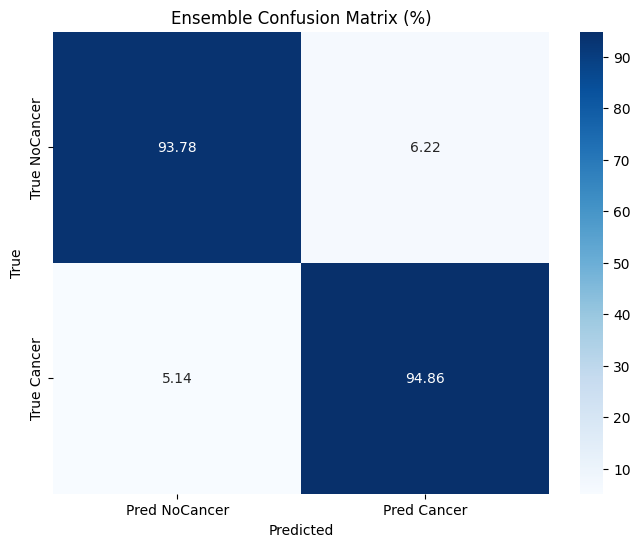

In [19]:
# # ### REFACTORED: Step 3 - Directly evaluate on the Test Set ###
# The val_loader and find_optimal_ensemble_threshold call are REMOVED.
print("\n--- Evaluating Ensemble Performance on Hold-Out Test Set ---")
ensemble_metrics = None
try:
    ensemble_metrics = analyze_ensemble_metrics(
        models_list=ensemble_models,
        model_weights=optimal_weights,      # Use weights from the recipe
        test_loader=test_loader,
        device=device,
        optimal_threshold=optimal_threshold # Use threshold from the recipe
    )
except Exception as e:
    print(f"Error during final ensemble evaluation: {e}")
    import traceback; traceback.print_exc()

In [24]:
# --- Visualization & Reporting (Adjusted for final return structure) ---
if ensemble_metrics:
    print("\n--- Visualizing Ensemble Predictions on Test Set ---")
    visualize_ensemble_predictions(
        models_list=ensemble_models,
        model_weights=optimal_weights,
        dataloader=test_loader,
        device=device,
        threshold=optimal_threshold,
        num_samples=5
    )

    ### REFACTORED: Final summary reporting from returned object ###
    # The analyze_ensemble_metrics function now prints its own detailed summary.
    # This section re-prints that summary from the returned object for final confirmation and logging.
    print("\n" + "="*20 + " Final Summary From Returned Object " + "="*20)

    # Extract the main results dictionaries
    micro_results = ensemble_metrics.get('micro_averaged_metrics')
    macro_results = ensemble_metrics.get('macro_averaged_metrics')
    auc_score = ensemble_metrics.get('auc')

    if not micro_results or not macro_results:
        print("Evaluation produced no valid metrics.")
    else:
        # --- Print the Micro-Averages with their CIs ---
        print("\n--- Overall Pixel-Level Metrics (Micro-Averages) ---")
        micro_pes = micro_results.get('point_estimate', {})
        micro_cis = micro_results.get('ci', {})

        for metric in sorted(micro_pes.keys()):
            pe = micro_pes[metric]
            ci = micro_cis.get(metric, [0.0, 0.0])
            print(f"  {metric.replace('_',' ').title():<12}: {pe:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")

        # Report the AUC score
        if auc_score is not None:
            print(f"  {'AUC':<12}: {auc_score:.4f}  (CI not calculated via bootstrap)")


        # --- Print the Macro-Averages with their CIs ---
        print("\n--- Mean Per-Image Metrics (Macro-Averages) ---")
        macro_pes = macro_results.get('point_estimate', {})
        macro_cis = macro_results.get('ci', {})

        for metric in sorted(macro_pes.keys()):
            pe = macro_pes[metric]
            ci = macro_cis.get(metric, [0.0, 0.0])
            print(f"  {metric.replace('_',' ').title():<12}: {pe:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")

else:
    print("\nEnsemble evaluation failed.")

# --- ADD THE CUSTOMIZED REPORT CALL HERE ---
if ensemble_metrics:
    print_scientific_analysis_report(ensemble_metrics)

print("\n--- Final Evaluation Script Finished ---")

Output hidden; open in https://colab.research.google.com to view.